# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Submission Instructions

Submit only a link to the folder for Assignment 2 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment2.ipynb` or something similar, placed inside the `assignments/assignment2/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

Claude Sonnet 4.6 (Anthropic) and ChatGPT was used in all tasks, mainly to debug, help with data analysis steps and to recommend good common coding practices. AI was heavily used in Tasks 5 and 6 to construct SQL queries, and for developing the MarketStack API request format in Task 2. AI was also used to check the final version of this file vs. the instructions in each task to ensure that my answers matched what was asked for in each subquestion.

## Grading

This assignment is worth 10 points. Task 0 is worth 2 points, and tasks 1-8 are worth 1 point each.

Points are given only for code that runs. If the code does not run, the task will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).

---

## Tasks

### Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)

### a) Dataset source

**Dataset:** Helsinki Region Infoshare (HSL)/ City Bike Finland: City bike stations’ Origin-Destination (OD) data. 

Download link to data set used: `https://dev.hsl.fi/citybikes/od-trips-2021/2021-07.csv`


*More can be found on these websites:*

`https://hri.fi/data/en_GB/dataset/helsingin-ja-espoon-kaupunkipyorilla-ajatut-matkat`

`https://www.hsl.fi/hsl/avoin-data#kaupunkipyorilla-ajetut-matkat`

A companion station metadata file (coordinates, names, city and so on) is available from HSL's portal:  
`https://opendata.arcgis.com/datasets/726277c507ef4914b0aec3cbcfcbfafc_0.csv
`





### b) Dataset description

**Current project plan**: Analyze when, where and how do people in Helsinki ride? I plan to look in to time-related patterns (hour of day, weekends vs. weekdays), trip distance, duration of trips and in which areas people take the most 


The dataset contains one row per bike trip made with Helsinki/Espoo city bikes. Each row has:

- `Departure` / `Return` — timestamps of trip start and end
- `Departure station id` / `Departure station name` — origin dock
- `Return station id` / `Return station name` — destination dock
- `covered_distance` — trip distance in metres
- `duration` — tripioneconds


Data is available from 2016 onwards, April–October each year. A single month (July 2021) contains roughly 350 000 rows, and the total amount of rows is 1 176 114 after cleps.   

In [11]:
# Task 0c — Load one month of city bike data and the station metadata

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Note that it takes a while to run the cell

# Load July 2021 trip data directly from the HSL open data server
trips_url = "https://dev.hsl.fi/citybikes/od-trips-2021/2021-07.csv"
df = pd.read_csv(trips_url)

# Load station metadata (names, coordinates, city)
stations_url = "https://opendata.arcgis.com/datasets/726277c507ef4914b0aec3cbcfcbfafc_0.csv"
stations = pd.read_csv(stations_url)

print("Trip data shape:", df.shape)
display(df.head())

Trip data shape: (1208844, 8)


,Departure,Return,Departure station id,Departure station name,Return station id,Return station name,Covered distance (m),Duration (sec.)
0,2021-07-31T23:59:59,2021-08-01T00:09:15,113,Pasilan asema,78,Messeniuksenkatu,1602.0,553
1,2021-07-31T23:59:55,2021-08-01T00:08:45,135,Velodrominrinne,115,Venttiilikuja,1307.0,532
2,2021-07-31T23:59:55,2021-08-01T00:03:24,258,Abraham Wetterin tie,260,Herttoniemi (M),820.0,205
3,2021-07-31T23:59:47,2021-08-01T00:05:52,122,Lintulahdenkatu,16,Liisanpuistikko,1298.0,369
4,2021-07-31T23:59:33,2021-08-01T00:14:49,126,Kalasatama (M),255,Laivalahden puistotie,3875.0,912


In [12]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(".", "", regex=False)
)

print(df.columns)

# Convert dates
df['departure'] = pd.to_datetime(df['departure'], errors='coerce')
df['return'] = pd.to_datetime(df['return'], errors='coerce')

# Create features for later analysis
df["hour"] = df["departure"].dt.hour 
df = df.dropna(subset=["hour"]) # Remove missing observations 
df["hour"] = df["hour"].astype(int)

df["day_of_week"] = df["departure"].dt.day_name()
df["date"] = df["departure"].dt.date

# Convert units
df["distance_km"] = df["covered_distance_m"] / 1000
df["duration_min"] = df["duration_sec"] / 60

# Remove unrealistic observations
df = df[(df["duration_sec"] >= 10) & (df["covered_distance_m"] > 0)]

print("Rows after basic cleaning:", len(df))
df[["duration_min", "distance_km"]].describe().round(2)


Index(['departure', 'return', 'departure_station_id', 'departure_station_name',
       'return_station_id', 'return_station_name', 'covered_distance_m',
       'duration_sec'],
      dtype='object')
Rows after basic cleaning: 1176108


,duration_min,distance_km
count,1176108.00,1176108.00
mean,18.16,2.51
std,220.99,1.80
min,0.17,0.00
25%,6.85,1.21
50%,11.48,2.08
75%,18.33,3.38
max,65910.47,53.25


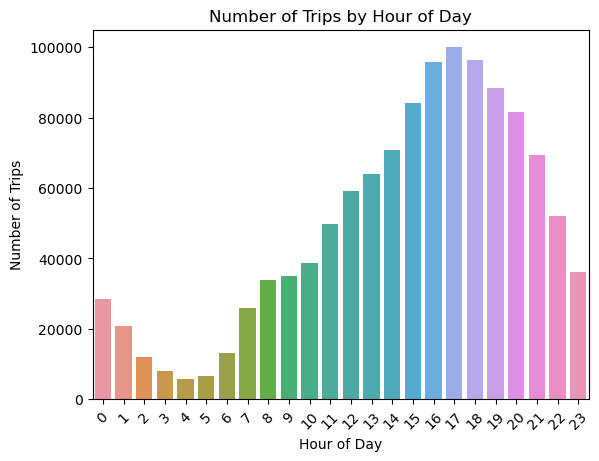

In [13]:
# Visualisation 1 - trips per hour of day
plt.figure()
sns.countplot(x="hour", data=df, order=range(24))
plt.xticks(rotation=45)
plt.title("Number of Trips by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

C:\Users\Win11\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


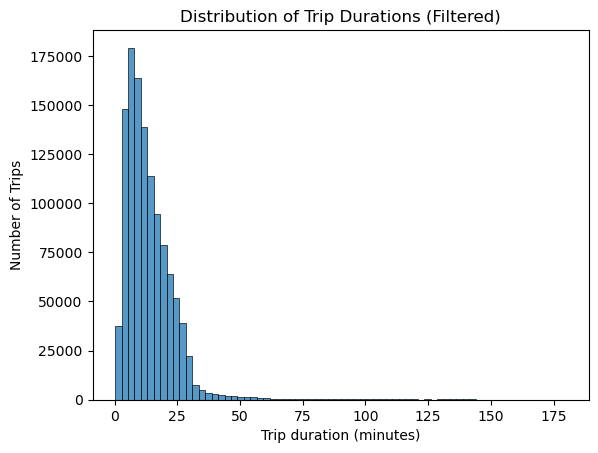

In [14]:
# Visualization 2: Distribution of trip durations
df_filtered = df[df["duration_min"] <= 180]  # keep trips ≤ 3 hours, otherwise the outliers blow up the visualization  

plt.figure()
sns.histplot(df_filtered["duration_min"], bins=70)
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Durations (Filtered)")
plt.show()

### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [16]:
# Task 1 - Load the MarketStack API key from a .env file
# The .env file is listed in .gitignore)

from dotenv import load_dotenv
import os

# Load all variables from .env into the environment
load_dotenv()
api_key = os.environ.get("MARKETSTACK_API_KEY")

if api_key:
    # Only print the first 5 characters to confirm the key loaded without exposing it
    print(f"API key loaded: {api_key[:5]}...")
else:
    print("ERROR: MARKETSTACK_API_KEY not found. Check your .env file.")

API key loaded: 0e3cb...


### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [18]:
# Task 2a - Retrieve end-of-day stock data for FAANG stocks in March 2026
import requests

# FAANG tickers
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

# API endpoint and parameters
url = "http://api.marketstack.com/v1/eod"
params = {
    "access_key": api_key,
    "symbols": ",".join(tickers),  # Comma-separated list of tickers
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "limit": 1000  # High limit to ensure we get all trading days for all stocks
}

response = requests.get(url, params=params)
print("Status code:", response.status_code)

# Store the raw JSON for Task 4
raw_json = response.json()
print(f"Total records retrieved: {len(raw_json['data'])}")

Status code: 200
Total records retrieved: 110


In [19]:
# Task 2b - Convert the JSON to a DataFrame

df_stocks = pd.DataFrame(raw_json["data"])

# Convert the date column to datetime for easier handling later
df_stocks["date"] = pd.to_datetime(df_stocks["date"])

print("Shape:", df_stocks.shape)
display(df_stocks.head())

Shape: (110, 15)


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00


In [20]:
# Task 2c - Summary stats for closing prices grouped by stock

# Summary stats per ticker
closing_stats = df_stocks.groupby("symbol")["close"].describe()
display(closing_stats)

print()


# Calculate monthly return percentage for each stock:
# Holding period return (%) = (last closing price - first closing price) / first closing price * 100

# Sort by date so first/last are chronologically correct
df_sorted = df_stocks.sort_values("date")

returns = df_sorted.groupby("symbol")["close"].agg(
    first_close="first",
    last_close="last"
)
returns["return_pct"] = (returns["last_close"] - returns["first_close"]) / returns["first_close"] * 100
returns["return_pct"] = returns["return_pct"].round(2)

display(returns)

best = returns["return_pct"].idxmax()
worst = returns["return_pct"].idxmin()
print(f"\nBest performer in March 2026:  {best} ({returns.loc[best, 'return_pct']}%)")
print(f"Worst performer in March 2026: {worst} ({returns.loc[worst, 'return_pct']}%)")

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


,first_close,last_close,return_pct
symbol,,,
AAPL,264.72,253.79,-4.13
AMZN,208.39,208.27,-0.06
GOOG,306.36,286.86,-6.37
META,653.56,572.13,-12.46
NFLX,97.09,96.15,-0.97



Best performer in March 2026:  AMZN (-0.06%)
Worst performer in March 2026: META (-12.46%)


### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

C:\Users\Win11\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Win11\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


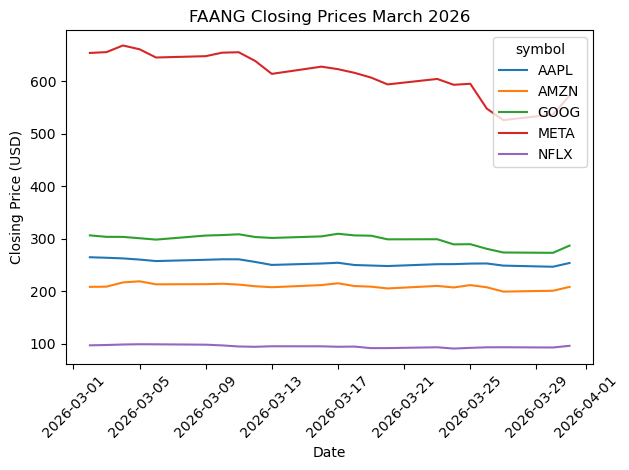

In [22]:
# Task 3a — Line chart: closing price of each stock over March 2026

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df_stocks, x="date", y="close", hue="symbol")
plt.title("FAANG Closing Prices March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

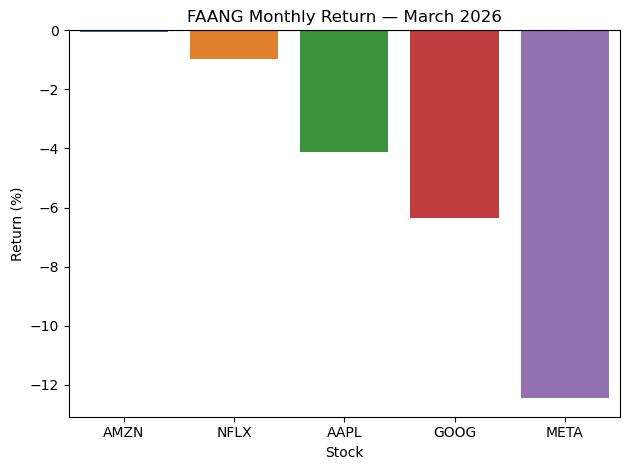

In [23]:
# Task 3b — Bar plot: overall return percentage for each stock in March 2026

# Reset index so 'symbol' becomes a regular column for seaborn
returns_reset = returns.reset_index()

# Sort bars from highest to lowest return
order = returns_reset.sort_values("return_pct", ascending=False)["symbol"]

sns.barplot(data=returns_reset, x="symbol", y="return_pct", order=order)
plt.title("FAANG Monthly Return — March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")  # Zero line for reference
plt.tight_layout()
plt.show()

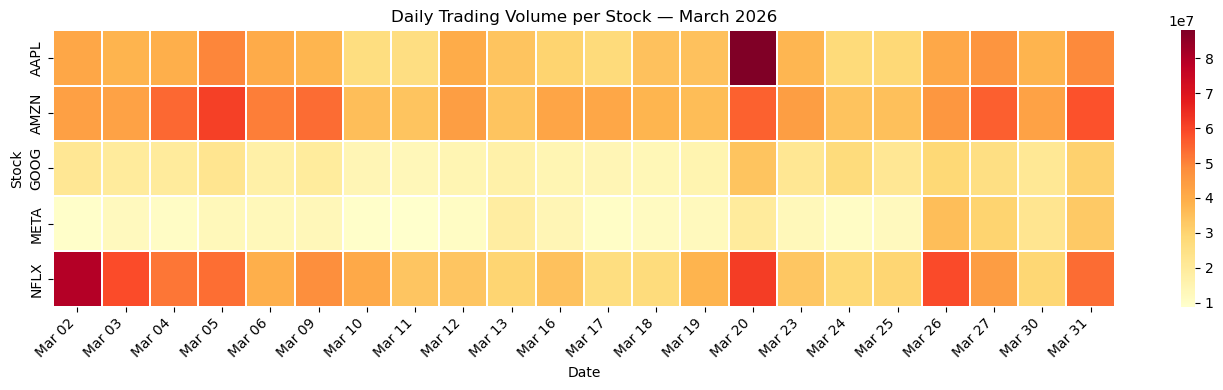

In [24]:
# Task 3c - Heatmap: daily trading volume per stock

# Pivot to wide format (such that rows = stocks, columns = dates)
volume_pivot = df_stocks.pivot(index="symbol", columns="date", values="volume")

# Format dates as strings for cleaner axis labels
volume_pivot.columns = volume_pivot.columns.strftime("%b %d")

plt.figure(figsize=(14, 4))
sns.heatmap(volume_pivot, cmap="YlOrRd", linewidths=0.3)
plt.title("Daily Trading Volume per Stock — March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Task 4: Exporting and importing data (1p)

a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`.

b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [26]:
# Task 4a — Export the raw JSON data to exports/stockdata.json

import json
import os

# Create the exports directory if it does not already exist
os.makedirs("exports", exist_ok=True)

with open("exports/stockdata.json", "w") as f:
    json.dump(raw_json, f, indent=2)

print("JSON exported to exports/stockdata.json")

JSON exported to exports/stockdata.json


In [27]:
# Task 4b — Export the DataFrame to exports/stockdata.csv

df_stocks.to_csv("exports/stockdata.csv", index=False)
print("CSV exported to exports/stockdata.csv")

CSV exported to exports/stockdata.csv


In [28]:
# Task 4c — Reload both files and verify the data looks the same

# Reload JSON
with open("exports/stockdata.json", "r") as f:
    reloaded_json = json.load(f)

df_from_json = pd.DataFrame(reloaded_json["data"])
print("Reloaded from JSON — first 5 rows:")
display(df_from_json.head())
print()

# Reload CSV
df_from_csv = pd.read_csv("exports/stockdata.csv")
print("Reloaded from CSV — first 5 rows:")
display(df_from_csv.head())

# Quick shape check can also be used to confirm that both match the original
print(f"\nOriginal shape: {df_stocks.shape}")
print(f"From JSON shape: {df_from_json.shape}")
print(f"From CSV shape:  {df_from_csv.shape}")


Reloaded from JSON — first 5 rows:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000



Reloaded from CSV — first 5 rows:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00



Original shape: (110, 15)
From JSON shape: (110, 15)
From CSV shape:  (110, 15)


### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

```
    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
```

Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [30]:
# Task 5a - Connect to the Northwind SQLite database and list all tables

import sqlite3

connection = sqlite3.connect("data/northwind.db")
db = connection.cursor()

db.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = db.fetchall()

print("Tables in the Northwind database:")
for table in tables:
    print(table[0])

Tables in the Northwind database:
Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [31]:
# Task 5b - Products with unit price above 30

query_5b = """
    SELECT ProductName, UnitPrice, UnitsInStock
    FROM Products
    WHERE UnitPrice > 30
"""

df_products = pd.read_sql_query(query_5b, connection)
print(f"Products with UnitPrice > 30: {len(df_products)} rows")
display(df_products)

Products with UnitPrice > 30: 24 rows


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [32]:
# Task 5c - Orders shipped to Germany: join Orders, Customers, and Order Details
# Note: 'Order Details' has a space in its name, so it must be quoted


# Note the "Order Details". 
query_5c = """
SELECT 
    c.CompanyName,
    o.OrderID,
    o.OrderDate,
    o.ShipCountry,
    od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c 
    ON o.CustomerID = c.CustomerID
JOIN "Order Details" od 
    ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
ORDER BY o.OrderID;
"""

df_orders_germany = pd.read_sql_query(query_5c, connection)

print(f"Rows returned: {len(df_orders_germany)}")
display(df_orders_germany.head())

Rows returned: 80673


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0


### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue (`UnitPrice * Quantity`) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

```
    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1
```

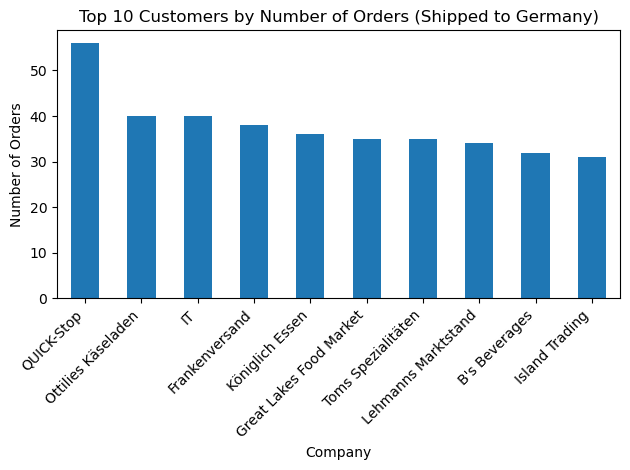

In [34]:
# Task 6a — Bar plot: number of orders per customer (top 10, Germany shipments from task 5)

# Count distinct OrderIDs per company to avoid counting each order line separately
orders_per_customer = (
    df_orders_germany.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

orders_per_customer.plot.bar()
plt.title("Top 10 Customers by Number of Orders (Shipped to Germany)")
plt.xlabel("Company")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

C:\Users\Win11\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


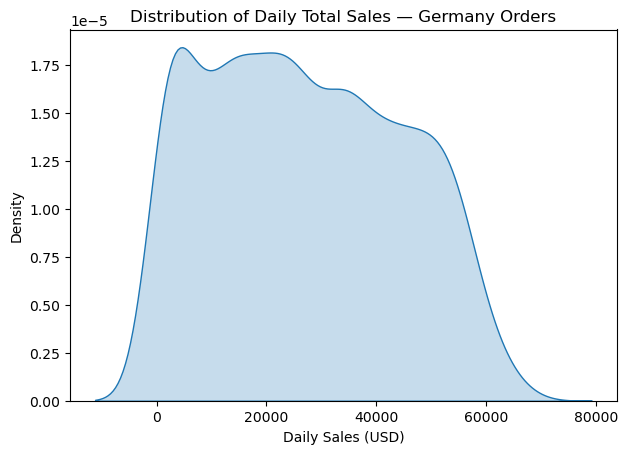

In [35]:
# Task 6b — Density plot: distribution of daily total sales for Germany orders


# Convert OrderDate
df_orders_germany["OrderDate"] = pd.to_datetime(
    df_orders_germany["OrderDate"],
    format="mixed",
    errors="coerce"
)
# Drop rows where date conversion failed
df_orders_germany = df_orders_germany.dropna(subset=["OrderDate"])

# Aggregate sales by date
daily_sales_germany = df_orders_germany.groupby("OrderDate")["LineTotal"].sum()

sns.kdeplot(daily_sales_germany, fill=True)
plt.title("Distribution of Daily Total Sales — Germany Orders")
plt.xlabel("Daily Sales (USD)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

Revenue per category:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


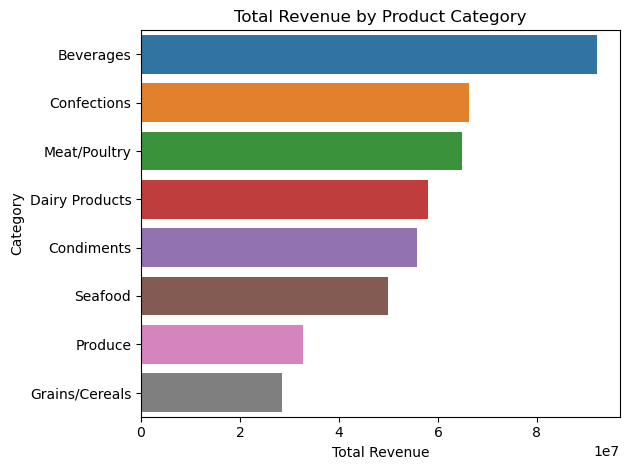

In [36]:
# Task 6c - total revenue by cateogry visualization + joins

query_6c = """
SELECT 
    c.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p
    ON od.ProductID = p.ProductID
JOIN Categories c
    ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;
"""

df_revenue_category = pd.read_sql_query(query_6c, connection)

print("Revenue per category:")
display(df_revenue_category)

plt.figure()
sns.barplot(
    x="TotalRevenue",
    y="CategoryName",
    data=df_revenue_category
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Task 7: Comparing Python to SQL (1p)

a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [38]:
# Task 7a

# Load full tables into separate dataframes
query_products = "SELECT * FROM Products"
query_categories = "SELECT * FROM Categories"

df_products_full = pd.read_sql_query(query_products, connection)
df_categories_full = pd.read_sql_query(query_categories, connection)

# Print first 5 rows for both Products and Categories
print("Products table (first 5 rows):")
display(df_products_full.head())

print()
print("Categories table (first 5 rows):")
display(df_categories_full.head())

Products table (first 5 rows):


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1



Categories table (first 5 rows):


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [39]:
# Task 7b - Inner join on CategoryID
df_products_categories = pd.merge(
    df_products_full,
    df_categories_full,
    on="CategoryID",
    how="inner"
)

print("Joined Products + Categories (first 5 rows):")
display(df_products_categories.head())

Joined Products + Categories (first 5 rows):


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.0,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.0,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,24,Guaraná Fantástica,10,1,12 - 355 ml cans,4.5,20,0,0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,34,Sasquatch Ale,16,1,24 - 12 oz bottles,14.0,111,0,15,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,35,Steeleye Stout,16,1,24 - 12 oz bottles,18.0,20,0,15,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [40]:
# Task 7c - speed comparison

import time


# Method 1: Full join and aggregation in SQL
query_7c_sql = """
SELECT 
    c.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p
    ON od.ProductID = p.ProductID
JOIN Categories c
    ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;
"""

start_sql = time.time()
df_sql_result = pd.read_sql_query(query_7c_sql, connection)
end_sql = time.time()

sql_time = end_sql - start_sql

print("SQL result:")
display(df_sql_result)

print(f"SQL execution time: {sql_time:.6f} seconds")



SQL result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


SQL execution time: 0.973610 seconds


In [41]:
# 7c, Method 2: Retrieve full tables and join in pandas
start_py = time.time()

# Load full tables from SQL
df_order_details = pd.read_sql_query('SELECT * FROM "Order Details"', connection)
df_products = pd.read_sql_query('SELECT * FROM Products', connection)
df_categories = pd.read_sql_query('SELECT * FROM Categories', connection)

# Join Order Details with Products
df_join_1 = pd.merge(df_order_details, df_products, on="ProductID", how="inner")

# Join the result with Categories
df_join_2 = pd.merge(df_join_1, df_categories, on="CategoryID", how="inner")

# Compute line revenue
df_join_2["Revenue"] = df_join_2["UnitPrice_x"] * df_join_2["Quantity"]

# Aggregate revenue by category
df_python_result = (
    df_join_2.groupby("CategoryName", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "TotalRevenue"})
    .sort_values("TotalRevenue", ascending=False)
)

end_py = time.time()

python_time = end_py - start_py

print("Pandas result:")
display(df_python_result)

print(f"Pandas execution time: {python_time:.6f} seconds")
print()

# Compare execution times
print(f"SQL execution time:    {sql_time:.6f} seconds")
print(f"Pandas execution time: {python_time:.6f} seconds")

print("Python (Pandas) was almost two times slower than SQL, mainly because the Python method requires loading the whole table first and then performing joins")
print("while in SQL the joins and aggregation is performed directly in the database engine")

Pandas result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
2,Confections,66347544.94
5,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
1,Condiments,55802774.45
7,Seafood,49931965.52
6,Produce,32706403.90
4,Grains/Cereals,28573512.55


Pandas execution time: 1.379840 seconds

SQL execution time:    0.973610 seconds
Pandas execution time: 1.379840 seconds
Python (Pandas) was almost two times slower than SQL, mainly because the Python method requires loading the whole table first and then performing joins
while in SQL the joins and aggregation is performed directly in the database engine


### Task 8: Wide and long format (1p)

You are given two datasets. The first is in wide format:

```python
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
```

The second is in long format:

```python
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
```

a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion.

b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [43]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})



# Task 8a - Convert wide_data from wide to long format using pd.melt()

print("wide_data BEFORE melt:")
display(wide_data)

# var_name: name for the new column that holds the old column headers
# value_name: name for the new column that holds the values
wide_to_long = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("wide_data AFTER melt (long format):")
display(wide_to_long)

wide_data BEFORE melt:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


wide_data AFTER melt (long format):


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [44]:
# Task 8b - Convert long_data from long to wide format using .pivot()

print("long_data BEFORE pivot:")
display(long_data)

# index: column whose values become the row labels
# columns: column whose values become the new column headers
# values: column whose values fill the cells
long_to_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
).rename_axis(columns=None).reset_index()

print("long_data AFTER pivot (wide format):")
display(long_to_wide)

long_data BEFORE pivot:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


long_data AFTER pivot (wide format):


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [45]:
# Task 8c — Convert both transformed datasets back to their original format

# --- wide_to_long → back to wide ---
# pivot() is the inverse of melt()
long_back_to_wide = wide_to_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).rename_axis(columns=None).reset_index()

# Restore original column order
original_cols = ["store", "Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"]
long_back_to_wide = long_back_to_wide[original_cols]

print("Reconstructed wide_data (should match original):")
display(wide_data)
display(long_back_to_wide)
print("Matches original wide_data:", wide_data.equals(long_back_to_wide))


Reconstructed wide_data (should match original):


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Matches original wide_data: True


In [46]:
# --- long_to_wide → back to long ---
# melt() is the inverse of pivot()
wide_back_to_long = pd.melt(
    long_to_wide,
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

# Restore original row order (pivot sorts alphabetically by month index)
month_order = ["Jan", "Feb", "Mar"]
wide_back_to_long["month"] = pd.Categorical(wide_back_to_long["month"], categories=month_order, ordered=True)
wide_back_to_long = wide_back_to_long.sort_values(["month", "product"]).reset_index(drop=True)

# Also sort the original for a fair comparison
long_data_sorted = long_data.copy()
long_data_sorted["month"] = pd.Categorical(long_data_sorted["month"], categories=month_order, ordered=True)
long_data_sorted = long_data_sorted.sort_values(["month", "product"]).reset_index(drop=True)

print("Reconstructed long_data (should match original):")
display(long_data)
display(wide_back_to_long)
print("Matches original long_data:", long_data_sorted.equals(wide_back_to_long))

Reconstructed long_data (should match original):


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


Matches original long_data: True
